# Multi-Turn Agent Memory: MemoryCompressor vs LangGraph-Style Strategies

**Goal**: Demonstrate how MemoryCompressor handles multi-turn agent sessions compared to the memory strategies available in LangGraph and similar frameworks.

### The problem

LangGraph provides **persistence infrastructure** (checkpointers, memory stores) but does NOT solve the **compression problem**. When a 20-turn conversation enters the context window, frameworks offer three options:

| Strategy | Framework Example | Failure Mode |
|----------|------------------|--------------|
| Keep everything | LangGraph checkpointer | Token overflow, attention degradation, rising cost |
| Trim old messages | `trim_messages(strategy='last')` | Permanently loses early decisions and constraints |
| Running summary + recent | `ConversationSummaryBufferMemory` | Summary loses numbers, entities, and rationale over time |

MemoryCompressor is the **compression layer** these frameworks are missing.

### Experiment Design

| Factor | Value |
|--------|-------|
| **Input** | 20-turn product planning session with requirements, decisions, pivots |
| **Conditions** | A. Full history, B. Sliding window (last 8), C. Summary + recent, D. MemoryCompressor + recent |
| **Recall probes** | 10 questions requiring recall from different conversation phases |

### Metrics

| Metric | What it measures |
|--------|------------------|
| **Recall accuracy** | Can the LLM correctly answer from memory alone? |
| **Input tokens** | Cost proxy — tokens sent to the LLM per probe |
| **Early-turn recall** | Accuracy on turns 1-7 info (sliding window failure) |
| **Pivot recall** | Accuracy on changed/updated info (summary failure) |

In [1]:
import json
import os
import time
from datetime import datetime

import tiktoken

os.environ.setdefault('OPENAI_API_KEY', os.environ.get('OPENAI_API_KEY', 'sk-...'))
PROVIDER = 'openai'

enc = tiktoken.encoding_for_model('gpt-4o')
def count_tokens(text):
    return len(enc.encode(text))

print('Setup complete.')

Setup complete.


## Step 1 — Multi-Turn Conversation

A 20-turn product planning session between a user and an AI assistant. The conversation evolves through four phases:

- **Turns 1-7**: Requirements gathering — tech stack, budget, team, compliance
- **Turns 8-14**: Architecture decisions — database, API, deployment, trade-offs
- **Turns 15-18**: Pivots — investor feedback changes scope, timeline shifts, budget reallocation
- **Turns 19-20**: New stakeholder — security audit adds requirements, priorities shift

Key challenge: turns 15-18 **override** decisions from turns 8-14. A good memory system must track what changed.

In [2]:
TURNS = [
    {"role": "user", "content": "I want to build a SaaS analytics platform called DataPulse. We're a team of 5 engineers, budget is $120K for the first 6 months. Our target market is mid-market B2B companies with 100-500 employees. We need SOC 2 compliance from day one because our first client, Meridian Health, requires it in their contract."},

    {"role": "assistant", "content": "Got it. DataPulse — SaaS analytics, 5 engineers, $120K/6mo budget, SOC 2 required for Meridian Health. What kind of analytics? Real-time dashboards, batch reporting, or both? And what data sources will you ingest — APIs, databases, file uploads?"},

    {"role": "user", "content": "Both real-time and batch. Primary data sources are PostgreSQL databases and REST APIs from our clients' systems. We also need CSV upload for historical data imports. Our CTO, Rachel Kim, wants us to use TypeScript for the backend and React for the frontend. She's insistent on that — no Python backend."},

    {"role": "assistant", "content": "Clear. TypeScript backend (per Rachel Kim, CTO), React frontend. Real-time + batch analytics. Data ingestion: PostgreSQL, REST APIs, CSV uploads. For the TypeScript backend, I'd suggest NestJS for the API layer — it has strong TypeScript support and built-in module system. For real-time, you'll want WebSockets via Socket.io or a message queue like BullMQ backed by Redis. What's your latency requirement for the real-time dashboards?"},

    {"role": "user", "content": "Real-time dashboards need to update within 5 seconds of data arrival. That's the SLA we promised Meridian Health. Also, we need multi-tenancy — each client's data must be completely isolated. Meridian's compliance team specifically asked about data isolation in the SOC 2 review. Our DevOps lead, Tom Andersen, wants to deploy on AWS using EKS. He's already set up a staging cluster."},

    {"role": "assistant", "content": "Key requirements locked in:\n- 5-second real-time SLA for Meridian Health\n- Multi-tenancy with strict data isolation (SOC 2)\n- AWS EKS deployment (Tom Andersen, DevOps lead, has staging ready)\n\nFor multi-tenancy with isolation, you have two main options: schema-per-tenant in a shared database, or database-per-tenant. Schema-per-tenant is cheaper to operate but harder to scale past ~200 tenants. Database-per-tenant gives perfect isolation but costs more. With your B2B mid-market target (100-500 employee companies), you'll likely have dozens, not thousands, of tenants. Schema-per-tenant is probably the right call. What do you think?"},

    {"role": "user", "content": "Schema-per-tenant sounds right for our scale. Let's go with that. Oh, one more thing — our lead frontend engineer, Maya Chen, wants to use Tremor for the chart components. She evaluated Chart.js, Recharts, and Tremor, and Tremor won on design quality and TypeScript support. Also, our pricing model is $2,500/month per tenant for the standard tier and $7,500/month for enterprise tier which includes custom dashboards and API access."},

    {"role": "assistant", "content": "Decisions captured:\n- Multi-tenancy: schema-per-tenant\n- Charts: Tremor (Maya Chen's recommendation)\n- Pricing: $2,500/mo standard, $7,500/mo enterprise (custom dashboards + API)\n\nNow let's talk database. For the analytics workload — you'll have both OLTP (user management, tenant config) and OLAP (analytics queries, aggregations). My recommendation: PostgreSQL for OLTP and ClickHouse for the OLAP layer. ClickHouse handles columnar analytics at massive scale and is 10-100x faster than PostgreSQL for aggregation queries. The trade-off is added operational complexity. Alternatively, you could use TimescaleDB as an extension on PostgreSQL to keep everything in one database. What's your preference?"},

    {"role": "user", "content": "Let's go with ClickHouse for analytics. The performance advantage is too big to ignore. We'll use PostgreSQL for the OLTP layer and ClickHouse for OLAP. Tom says he can manage the operational complexity — he's run ClickHouse before at his previous company. What about the data pipeline between them?"},

    {"role": "assistant", "content": "Good choice. Architecture so far:\n- PostgreSQL (OLTP) + ClickHouse (OLAP)\n- Tom Andersen has ClickHouse experience\n\nFor the data pipeline between PostgreSQL and ClickHouse, I recommend Apache Kafka as the message broker. Flow: data arrives via REST API or CSV → lands in PostgreSQL → Change Data Capture (CDC) via Debezium streams changes to Kafka → Kafka consumer writes to ClickHouse. This gives you:\n1. Real-time sync (sub-second CDC)\n2. Replay capability if ClickHouse needs rebuilding\n3. Decoupled systems — if ClickHouse goes down, data buffers in Kafka\n\nEstimated infrastructure cost: ~$3,200/month for the full stack (EKS + RDS + ClickHouse Cloud + Kafka on MSK). That's $19,200 over 6 months — about 16% of your $120K budget."},

    {"role": "user", "content": "$3,200/month is fine, that leaves plenty for salaries and tooling. Let's lock in Kafka + Debezium for CDC. What about authentication? We need SSO for enterprise tier clients. Meridian Health uses Okta."},

    {"role": "assistant", "content": "For auth, I recommend Auth0 as your identity provider. It supports:\n- Okta integration via SAML/OIDC (covers Meridian Health)\n- SSO for enterprise tier\n- Multi-tenant user management\n- SOC 2 compliant\n\nAuth0 pricing at your scale: ~$240/month for the B2B plan (up to 500 MAUs per tenant). The alternative is building on AWS Cognito, which is cheaper ($0.0055/MAU) but has weaker SSO and multi-tenant support. Given your SOC 2 requirement and Meridian Health needing Okta, Auth0 is worth the premium. Total monthly infra estimate now: $3,440/month."},

    {"role": "user", "content": "Auth0 it is. So we've got the full stack defined. Can you summarize the architecture we've decided on?"},

    {"role": "assistant", "content": "Here's the complete DataPulse architecture:\n\n**Backend**: NestJS (TypeScript)\n**Frontend**: React + Tremor charts\n**OLTP Database**: PostgreSQL (schema-per-tenant)\n**OLAP Database**: ClickHouse\n**Data Pipeline**: Kafka (MSK) + Debezium CDC\n**Auth**: Auth0 (SSO via Okta for enterprise)\n**Deployment**: AWS EKS\n**Real-time**: WebSockets via Socket.io\n\n**Monthly infra**: ~$3,440\n**Team**: 5 engineers — Rachel Kim (CTO), Tom Andersen (DevOps), Maya Chen (Frontend Lead), + 2 others\n**Timeline**: MVP in 3 months, production launch month 4\n**First client**: Meridian Health (enterprise tier, $7,500/mo, requires SOC 2 + Okta SSO)\n\nShall I draft a sprint plan for the first 4 weeks?"},

    {"role": "user", "content": "Actually hold on. I just got out of a meeting with our lead investor, David Park from Sequoia. He wants us to pivot the product focus. Instead of general analytics, he wants us to specialize in healthcare analytics. His reasoning: the healthcare analytics market is $50B by 2027, and our Meridian Health relationship gives us domain credibility. This changes things — we now need HIPAA compliance in addition to SOC 2, and we need to support HL7 FHIR data format for healthcare interoperability."},

    {"role": "assistant", "content": "Major pivot. Let me capture what changes:\n\n**CHANGED**: Product focus from general analytics → healthcare analytics (David Park, Sequoia investor)\n**NEW requirement**: HIPAA compliance (in addition to SOC 2)\n**NEW requirement**: HL7 FHIR data format support\n**UNCHANGED**: Core architecture (NestJS, React, ClickHouse, Kafka)\n\nHIPAA implications:\n1. Data encryption at rest AND in transit (AES-256 + TLS 1.3)\n2. Audit logging for all data access — who accessed what, when\n3. Business Associate Agreements (BAAs) with all vendors — AWS has BAA, Auth0 has BAA, ClickHouse Cloud has BAA\n4. PHI data handling — no Protected Health Information in logs or error messages\n\nThis increases infra cost by roughly $800/month (encryption overhead, audit logging storage, HIPAA-compliant backups). New monthly estimate: ~$4,240/month — $25,440 over 6 months."},

    {"role": "user", "content": "Yeah, David is also increasing our budget. New total is $200K for 6 months instead of $120K. He's bringing in a healthcare data specialist, Dr. Sarah Okonkwo, who starts next month. She'll handle FHIR integration and domain-specific analytics modules. So team grows to 6. Also, timeline shifts — MVP now needs to be ready in 4 months instead of 3 because of the HIPAA work. Production launch month 5."},

    {"role": "assistant", "content": "Updated project state:\n\n**CHANGED**:\n- Budget: $120K → $200K for 6 months (David Park, Sequoia)\n- Team: 5 → 6 engineers (adding Dr. Sarah Okonkwo, healthcare data specialist, starts next month)\n- MVP timeline: 3 months → 4 months\n- Production launch: month 4 → month 5\n- Monthly infra: $3,440 → $4,240\n\n**NEW**:\n- HIPAA compliance required\n- HL7 FHIR support\n- Healthcare analytics specialization\n\n**UNCHANGED**:\n- Tech stack (NestJS, React+Tremor, PostgreSQL, ClickHouse, Kafka, Auth0, EKS)\n- Schema-per-tenant multi-tenancy\n- Meridian Health as first client\n- SOC 2 requirement\n- 5-second real-time SLA\n\nWith $200K and 6 people over 6 months, your burn rate is approximately $33K/month. Subtracting $4,240 for infra leaves ~$28,760/month for salaries and tooling. Shall I revise the sprint plan for the healthcare pivot?"},

    {"role": "user", "content": "Yes, but first — Rachel Kim just flagged something. ClickHouse Cloud doesn't have a signed BAA for HIPAA. We checked and they said it's 'coming Q3 2026.' That's too late. We need to either self-host ClickHouse on EKS (which Tom says adds 15 hours/week of operational overhead) or switch to a HIPAA-compliant alternative. What are our options?"},

    {"role": "assistant", "content": "Critical constraint. Options for HIPAA-compliant OLAP:\n\n1. **Self-host ClickHouse on EKS**: Best query performance, but 15 hrs/week ops overhead (Tom's estimate). With a 6-person team, that's significant.\n2. **Amazon Redshift Serverless**: HIPAA-compliant (AWS BAA covers it), columnar, good for analytics. ~2-5x slower than ClickHouse for point queries but comparable for aggregations. No ops overhead. Cost: ~$4,800/month (higher than ClickHouse Cloud's $1,200).\n3. **BigQuery** (Google Cloud): HIPAA-compliant, excellent for analytics, but you'd need to split across AWS and GCP — adds networking complexity.\n\nMy recommendation: **Redshift Serverless**. The cost increase ($4,800 vs $1,200 = +$3,600/month) is manageable with the $200K budget, and eliminating 15 hrs/week of ops work is worth ~$3,000/month in engineer time. Updated monthly infra: $3,440 - $1,200 (ClickHouse) + $4,800 (Redshift) = $7,040/month — $42,240 over 6 months."},

    {"role": "user", "content": "Let's go with Redshift Serverless. The ops overhead of self-hosting isn't worth it at our stage. So to confirm — we're now on PostgreSQL + Redshift instead of PostgreSQL + ClickHouse. The Kafka + Debezium pipeline stays the same, just the sink changes to Redshift. Oh and one more thing — our new security consultant, James Whitfield, just reviewed the architecture. He requires that all API endpoints implement rate limiting (1000 req/min per tenant) and that we add an API gateway — he recommends Kong. The SOC 2 auditor specifically flagged rate limiting as a control they'll check."},

    {"role": "user", "content": "Actually James also said we need a WAF (Web Application Firewall) in front of everything. He wants AWS WAF integrated with our ALB. And all database connections must go through AWS PrivateLink — no public endpoints. He gave us until the end of this week to confirm these security requirements are in the architecture plan."}
]

full_history_text = '\n\n'.join(f'{t["role"].upper()}: {t["content"]}' for t in TURNS)
print(f'Conversation: {len(TURNS)} turns, {count_tokens(full_history_text)} tokens, ~{len(full_history_text.split())} words')

Conversation: 22 turns, 2633 tokens, ~1689 words


## Step 2 — Memory Strategy Implementations

Four strategies, each replicating a real framework pattern without external dependencies:

| Strategy | Replicates | How |
|----------|-----------|-----|
| A. Full History | LangGraph checkpointer | All 20 turns in context |
| B. Sliding Window | `trim_messages(strategy='last', max=8)` | Last 8 messages only |
| C. Summary + Recent | `ConversationSummaryBufferMemory` | Running summary every 6 turns + last 4 raw |
| D. MemoryCompressor + Recent | **Our approach** | Structured state (session→progressive) + last 4 raw |

In [3]:
import litellm

from mycontext.core import Context
from mycontext.foundation import Directive
from mycontext.templates.free.specialized import MemoryCompressor

litellm.drop_params = True

mc = MemoryCompressor()

LANGCHAIN_SUMMARY_PROMPT = """Progressively summarize the lines of conversation provided, adding onto the previous summary returning a new summary.

EXAMPLE
Current summary:
The human asks what the AI thinks of artificial intelligence. The AI thinks artificial intelligence is a force for good.

New lines of conversation:
Human: Why do you think artificial intelligence is a force for good?
AI: Because artificial intelligence will help humans reach their full potential.

New summary:
The human asks what the AI thinks of artificial intelligence. The AI thinks artificial intelligence is a force for good because it will help humans reach their full potential.
END OF EXAMPLE

Current summary:
{summary}

New lines of conversation:
{new_lines}

New summary:"""


def build_full_history(turns):
    """Strategy A: pass all messages. LangGraph checkpointer default."""
    text = '\n\n'.join(f'{t["role"].upper()}: {t["content"]}' for t in turns)
    return f'[FULL CONVERSATION HISTORY]\n\n{text}'


def build_sliding_window(turns, k=8):
    """Strategy B: keep last k messages. LangGraph trim_messages(strategy='last')."""
    recent = turns[-k:]
    text = '\n\n'.join(f'{t["role"].upper()}: {t["content"]}' for t in recent)
    return f'[CONVERSATION — LAST {k} MESSAGES]\n\n{text}'


def build_summary_recent(turns, summary_interval=6, keep_recent=4):
    """Strategy C: running summary updated every N turns + last M raw messages.
    Replicates ConversationSummaryBufferMemory / LangGraph summary pattern."""
    to_summarize = turns[:-keep_recent]
    recent = turns[-keep_recent:]

    summary = ''
    for i in range(0, len(to_summarize), summary_interval):
        chunk_turns = to_summarize[i:i + summary_interval]
        chunk_text = '\n'.join(f'{t["role"].upper()}: {t["content"]}' for t in chunk_turns)
        prompt = LANGCHAIN_SUMMARY_PROMPT.replace('{summary}', summary or '(nothing yet)').replace('{new_lines}', chunk_text)
        ctx = Context(directive=Directive(content=prompt))
        res = ctx.execute(provider=PROVIDER)
        summary = res.response

    recent_text = '\n\n'.join(f'{t["role"].upper()}: {t["content"]}' for t in recent)
    return f'[CONVERSATION SUMMARY]\n{summary}\n\n[RECENT MESSAGES]\n\n{recent_text}'


def build_mc_recent(turns, compress_at=10, update_at=18, keep_recent=4):
    """Strategy D: MemoryCompressor structured state + last M raw messages.
    Session compression at turn 10, progressive update at turn 18."""
    # Phase 1: session compression of first 10 turns
    phase1_text = '\n\n'.join(f'{t["role"].upper()}: {t["content"]}' for t in turns[:compress_at])
    ctx1 = mc.build_context(content=phase1_text, intent='session')
    res1 = ctx1.execute(provider=PROVIDER)
    session_state = res1.response

    # Phase 2: progressive update with turns 10-18
    phase2_text = '\n\n'.join(f'{t["role"].upper()}: {t["content"]}' for t in turns[compress_at:update_at])
    ctx2 = mc.build_context(
        content=phase2_text,
        intent='progressive',
        existing_memory=session_state,
    )
    res2 = ctx2.execute(provider=PROVIDER)
    updated_state = res2.response

    recent = turns[-keep_recent:]
    recent_text = '\n\n'.join(f'{t["role"].upper()}: {t["content"]}' for t in recent)
    return f'[COMPRESSED MEMORY STATE]\n{updated_state}\n\n[RECENT MESSAGES]\n\n{recent_text}'


print('All 4 memory strategies defined.')

All 4 memory strategies defined.


## Step 3 — Recall Probes

10 questions that test recall from different conversation phases. Each has ground-truth markers with aliases for fair scoring.

- **Early (turns 1-7)**: Info that sliding window drops entirely
- **Mid (turns 8-14)**: Architecture decisions the summary tends to blur
- **Pivot (turns 15-18)**: Changed decisions — did the memory track the update?
- **Cross-ref**: Require combining info from multiple phases

In [4]:
PROBES = [
    # --- Early-turn recall (turns 1-7) — sliding window loses these ---
    {
        'id': 'E1',
        'category': 'early',
        'q': 'What is the original budget, team size, and who is the CTO?',
        'markers': ['120k', '120,000', '$120', '5 engineer', 'five engineer', 'rachel kim', 'rachel'],
        'min_hits': 3,
    },
    {
        'id': 'E2',
        'category': 'early',
        'q': 'What compliance standard is required by the first client, and who is that client?',
        'markers': ['soc 2', 'soc2', 'soc-2', 'meridian health', 'meridian'],
        'min_hits': 2,
    },
    {
        'id': 'E3',
        'category': 'early',
        'q': 'What chart library was chosen and who recommended it?',
        'markers': ['tremor', 'maya chen', 'maya'],
        'min_hits': 2,
    },
    # --- Mid-turn recall (turns 8-14) — summary blurs these ---
    {
        'id': 'M1',
        'category': 'mid',
        'q': 'What was the original OLAP database choice and the data pipeline architecture?',
        'markers': ['clickhouse', 'kafka', 'debezium', 'cdc', 'change data capture'],
        'min_hits': 3,
    },
    {
        'id': 'M2',
        'category': 'mid',
        'q': 'What authentication provider was selected and why?',
        'markers': ['auth0', 'okta', 'sso', 'saml', 'oidc', 'soc 2', 'soc2', 'hipaa', '$240', '240/month'],
        'min_hits': 3,
    },
    {
        'id': 'M3',
        'category': 'mid',
        'q': 'What is the pricing model for DataPulse?',
        'markers': ['2,500', '2500', '$2,500', '7,500', '7500', '$7,500', 'standard', 'enterprise'],
        'min_hits': 3,
    },
    # --- Pivot recall (turns 15-18) — did the memory track changes? ---
    {
        'id': 'P1',
        'category': 'pivot',
        'q': 'The OLAP database was changed from the original choice. What is it now and why did it change?',
        'markers': ['redshift', 'clickhouse', 'hipaa', 'baa', 'business associate'],
        'min_hits': 3,
    },
    {
        'id': 'P2',
        'category': 'pivot',
        'q': 'How did the budget and timeline change after the investor meeting? Who is the investor?',
        'markers': ['200k', '200,000', '$200', 'david park', 'sequoia', '4 month', 'four month', 'month 5', 'month five'],
        'min_hits': 3,
    },
    # --- Cross-reference (combine info from multiple phases) ---
    {
        'id': 'X1',
        'category': 'cross',
        'q': 'What is the current monthly infrastructure cost and how does it compare to the original estimate?',
        'markers': ['7,040', '7040', '$7,040', '3,440', '3440', '$3,440', '3,200', '3200', 'redshift', '4,800', '4800'],
        'min_hits': 3,
    },
    {
        'id': 'X2',
        'category': 'cross',
        'q': 'List all the security requirements mentioned by the security consultant. Who is the consultant?',
        'markers': ['james whitfield', 'rate limit', '1000', '1,000', 'kong', 'waf', 'web application firewall', 'privatelink', 'private link'],
        'min_hits': 4,
    },
]

print(f'Recall probes: {len(PROBES)} total')
for cat in ['early', 'mid', 'pivot', 'cross']:
    n = sum(1 for p in PROBES if p['category'] == cat)
    print(f'  {cat}: {n} questions')

Recall probes: 10 total
  early: 3 questions
  mid: 3 questions
  pivot: 2 questions
  cross: 2 questions


## Step 4 — Build Memory States & Run Probes

For each strategy:
1. Build the memory representation from the 20-turn conversation
2. Ask all 10 recall probes using only that memory
3. Record the answer, tokens used, and latency

In [5]:
STRATEGIES = [
    ('A_full_history', 'A. Full History (checkpointer)', lambda: build_full_history(TURNS)),
    ('B_sliding_window', 'B. Sliding Window (last 8)', lambda: build_sliding_window(TURNS, k=8)),
    ('C_summary_recent', 'C. Summary + Recent (LangGraph)', lambda: build_summary_recent(TURNS)),
    ('D_mc_recent', 'D. MemoryCompressor + Recent', lambda: build_mc_recent(TURNS)),
]

all_results = []
memory_states = {}

for strat_key, strat_label, build_fn in STRATEGIES:
    print(f'\n{"#" * 70}')
    print(f'Building memory: {strat_label}')
    print(f'{"#" * 70}')

    t0 = time.time()
    memory = build_fn()
    build_time = time.time() - t0
    memory_tokens = count_tokens(memory)
    memory_states[strat_key] = memory

    print(f'  Memory built in {build_time:.1f}s — {memory_tokens} tokens, ~{len(memory.split())} words')
    print(f'  Compression: {memory_tokens / count_tokens(full_history_text):.2f}x of full history')
    print(f'\n  Running {len(PROBES)} recall probes...')

    for probe in PROBES:
        prompt = (
            'You are an AI assistant. Use ONLY the provided conversation memory '
            'to answer the question. Be specific — include exact names, numbers, '
            'and details. If the information is not in the memory, say "NOT IN MEMORY".\n\n'
            f'MEMORY:\n{memory}\n\n'
            f'QUESTION: {probe["q"]}'
        )
        probe_tokens = count_tokens(prompt)

        t1 = time.time()
        ctx = Context(directive=Directive(content=prompt))
        res = ctx.execute(provider=PROVIDER)
        probe_time = time.time() - t1

        answer = res.response
        answer_lower = answer.lower()
        marker_hits = sum(1 for m in probe['markers'] if m.lower() in answer_lower)
        passed = marker_hits >= probe['min_hits']

        all_results.append({
            'strategy': strat_key,
            'probe_id': probe['id'],
            'category': probe['category'],
            'question': probe['q'],
            'answer': answer,
            'marker_hits': marker_hits,
            'marker_total': len(probe['markers']),
            'min_hits': probe['min_hits'],
            'passed': passed,
            'input_tokens': probe_tokens,
            'latency': probe_time,
        })

        status = 'PASS' if passed else 'FAIL'
        print(f'    [{status}] {probe["id"]} ({probe["category"]}): {marker_hits}/{len(probe["markers"])} markers — {probe["q"][:50]}...')

print(f'\nTotal probe results: {len(all_results)}')


######################################################################
Building memory: A. Full History (checkpointer)
######################################################################
  Memory built in 0.0s — 2640 tokens, ~1692 words
  Compression: 1.00x of full history

  Running 10 recall probes...
    [PASS] E1 (early): 5/7 markers — What is the original budget, team size, and who is...
    [PASS] E2 (early): 3/5 markers — What compliance standard is required by the first ...
    [PASS] E3 (early): 3/3 markers — What chart library was chosen and who recommended ...
    [PASS] M1 (mid): 5/5 markers — What was the original OLAP database choice and the...
    [PASS] M2 (mid): 6/10 markers — What authentication provider was selected and why?...
    [PASS] M3 (mid): 6/8 markers — What is the pricing model for DataPulse?...
    [PASS] P1 (pivot): 5/5 markers — The OLAP database was changed from the original ch...
    [PASS] P2 (pivot): 6/9 markers — How did the budget and timeline 

## Step 5 — Score & Analyze Results

In [6]:
def avg(lst):
    return sum(lst) / len(lst) if lst else 0

STRAT_LABELS = [
    ('A_full_history', 'A. Full History'),
    ('B_sliding_window', 'B. Sliding Window'),
    ('C_summary_recent', 'C. Summary+Recent'),
    ('D_mc_recent', 'D. MemoryCompress'),
]

full_tokens = count_tokens(full_history_text)

# --- Overall recall accuracy ---
print('=' * 80)
print('OVERALL RECALL ACCURACY (probes passed / total probes)')
print('=' * 80)
for skey, slabel in STRAT_LABELS:
    sr = [r for r in all_results if r['strategy'] == skey]
    passed = sum(1 for r in sr if r['passed'])
    total = len(sr)
    mem_tokens = count_tokens(memory_states[skey])
    ratio = mem_tokens / full_tokens
    print(f'  {slabel:<25} {passed}/{total} ({passed/total:.0%})   |  {mem_tokens:,} tokens ({ratio:.2f}x)')

# --- Recall by category ---
print()
print('=' * 80)
print('RECALL BY CATEGORY')
print('=' * 80)
for cat, cat_label in [('early', 'Early (turns 1-7)'), ('mid', 'Mid (turns 8-14)'), ('pivot', 'Pivot (turns 15-18)'), ('cross', 'Cross-reference')]:
    print(f'\n  {cat_label}:')
    for skey, slabel in STRAT_LABELS:
        sr = [r for r in all_results if r['strategy'] == skey and r['category'] == cat]
        passed = sum(1 for r in sr if r['passed'])
        total = len(sr)
        pct = f'{passed/total:.0%}' if total > 0 else 'N/A'
        print(f'    {slabel:<25} {passed}/{total} ({pct})')

# --- Token efficiency ---
print()
print('=' * 80)
print('TOKEN EFFICIENCY (accuracy per 1000 tokens of memory)')
print('=' * 80)
for skey, slabel in STRAT_LABELS:
    sr = [r for r in all_results if r['strategy'] == skey]
    passed = sum(1 for r in sr if r['passed'])
    total = len(sr)
    accuracy = passed / total
    mem_tokens = count_tokens(memory_states[skey])
    efficiency = (accuracy / mem_tokens) * 1000 if mem_tokens > 0 else 0
    print(f'  {slabel:<25} {efficiency:.4f} accuracy/1K tokens  (acc={accuracy:.0%}, tokens={mem_tokens:,})')

# --- Per-probe detail ---
print()
print('=' * 80)
print('PER-PROBE DETAIL')
print('=' * 80)
for probe in PROBES:
    print(f'\n  [{probe["id"]}] {probe["q"][:65]}...')
    for skey, slabel in STRAT_LABELS:
        r = next(r for r in all_results if r['strategy'] == skey and r['probe_id'] == probe['id'])
        status = 'PASS' if r['passed'] else 'FAIL'
        print(f'    {slabel:<25} [{status}] {r["marker_hits"]}/{r["marker_total"]} markers')

OVERALL RECALL ACCURACY (probes passed / total probes)
  A. Full History           10/10 (100%)   |  2,640 tokens (1.00x)
  B. Sliding Window         7/10 (70%)   |  1,199 tokens (0.46x)
  C. Summary+Recent         10/10 (100%)   |  1,990 tokens (0.76x)
  D. MemoryCompress         9/10 (90%)   |  1,351 tokens (0.51x)

RECALL BY CATEGORY

  Early (turns 1-7):
    A. Full History           3/3 (100%)
    B. Sliding Window         2/3 (67%)
    C. Summary+Recent         3/3 (100%)
    D. MemoryCompress         3/3 (100%)

  Mid (turns 8-14):
    A. Full History           3/3 (100%)
    B. Sliding Window         1/3 (33%)
    C. Summary+Recent         3/3 (100%)
    D. MemoryCompress         2/3 (67%)

  Pivot (turns 15-18):
    A. Full History           2/2 (100%)
    B. Sliding Window         2/2 (100%)
    C. Summary+Recent         2/2 (100%)
    D. MemoryCompress         2/2 (100%)

  Cross-reference:
    A. Full History           2/2 (100%)
    B. Sliding Window         2/2 (100%)
   

## Step 6 — Visualization

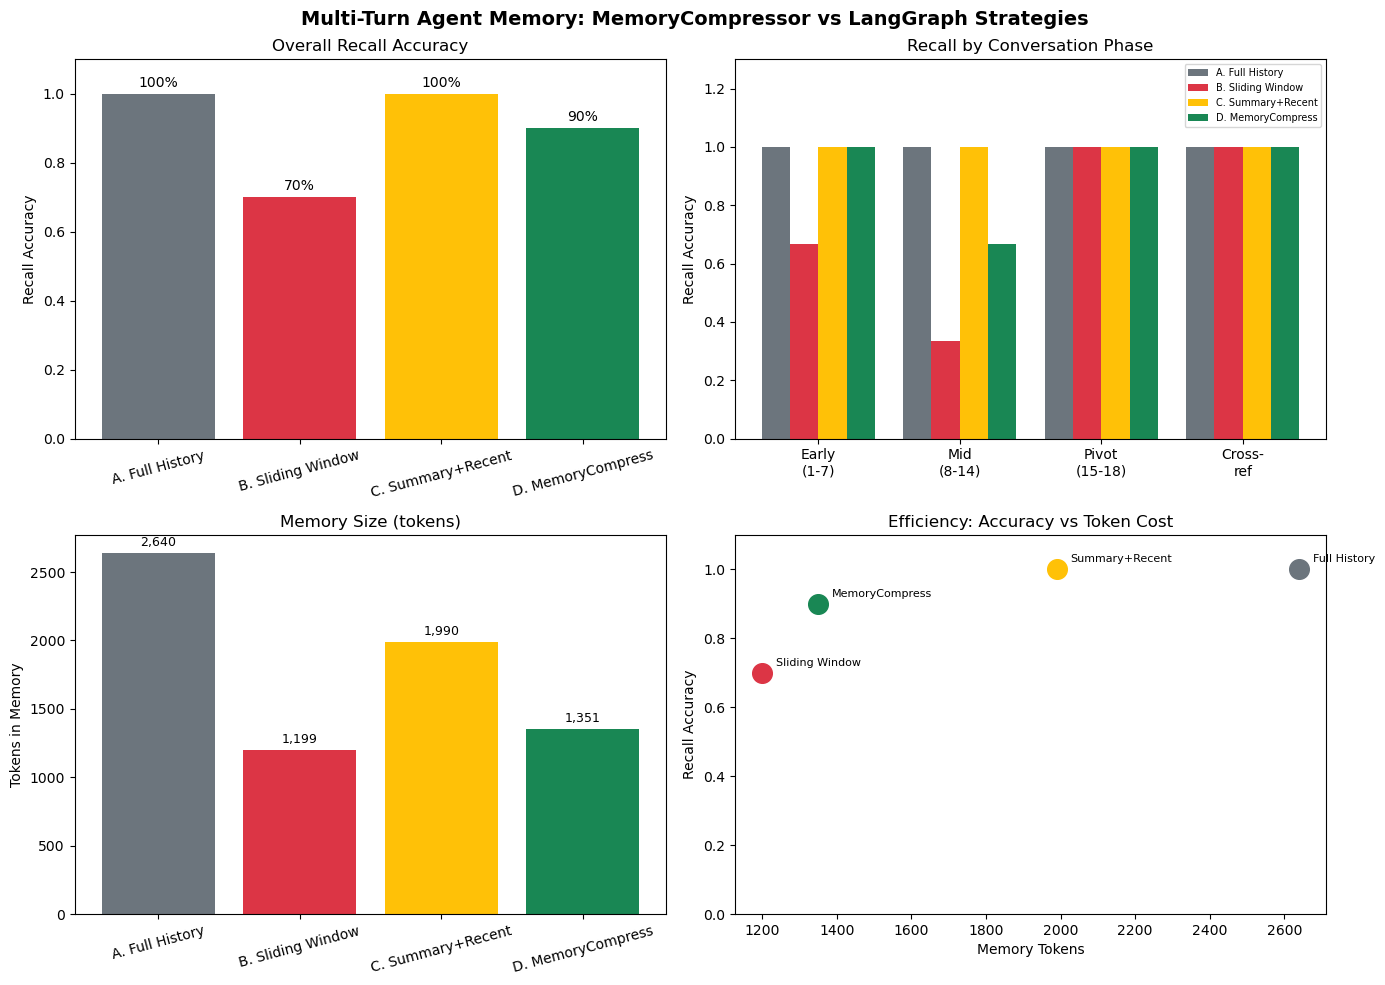

Chart saved to memory_compressor_multiturn_results.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Multi-Turn Agent Memory: MemoryCompressor vs LangGraph Strategies', fontsize=14, fontweight='bold')

strat_names = [sl for _, sl in STRAT_LABELS]
strat_keys = [sk for sk, _ in STRAT_LABELS]
colors = ['#6c757d', '#dc3545', '#ffc107', '#198754']

# --- 1. Overall recall accuracy ---
ax1 = axes[0, 0]
accuracies = []
for skey in strat_keys:
    sr = [r for r in all_results if r['strategy'] == skey]
    accuracies.append(sum(1 for r in sr if r['passed']) / len(sr))
bars1 = ax1.bar(strat_names, accuracies, color=colors)
ax1.set_ylabel('Recall Accuracy')
ax1.set_title('Overall Recall Accuracy')
ax1.set_ylim(0, 1.1)
for bar, val in zip(bars1, accuracies, strict=False):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.0%}', ha='center', fontsize=10)
ax1.tick_params(axis='x', rotation=15)

# --- 2. Recall by category (grouped bar) ---
ax2 = axes[0, 1]
categories = ['early', 'mid', 'pivot', 'cross']
cat_labels = ['Early\n(1-7)', 'Mid\n(8-14)', 'Pivot\n(15-18)', 'Cross-\nref']
x = np.arange(len(categories))
width = 0.2
for i, (skey, slabel) in enumerate(STRAT_LABELS):
    cat_accs = []
    for cat in categories:
        sr = [r for r in all_results if r['strategy'] == skey and r['category'] == cat]
        cat_accs.append(sum(1 for r in sr if r['passed']) / len(sr) if sr else 0)
    ax2.bar(x + i * width, cat_accs, width, label=slabel, color=colors[i])
ax2.set_xticks(x + 1.5 * width)
ax2.set_xticklabels(cat_labels)
ax2.set_ylabel('Recall Accuracy')
ax2.set_title('Recall by Conversation Phase')
ax2.set_ylim(0, 1.3)
ax2.legend(fontsize=7, loc='upper right')

# --- 3. Token usage ---
ax3 = axes[1, 0]
token_counts = [count_tokens(memory_states[sk]) for sk in strat_keys]
bars3 = ax3.bar(strat_names, token_counts, color=colors)
ax3.set_ylabel('Tokens in Memory')
ax3.set_title('Memory Size (tokens)')
for bar, val in zip(bars3, token_counts, strict=False):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{val:,}', ha='center', fontsize=9)
ax3.tick_params(axis='x', rotation=15)

# --- 4. Efficiency scatter ---
ax4 = axes[1, 1]
for i, (skey, slabel) in enumerate(STRAT_LABELS):
    sr = [r for r in all_results if r['strategy'] == skey]
    acc = sum(1 for r in sr if r['passed']) / len(sr)
    tokens = count_tokens(memory_states[skey])
    ax4.scatter(tokens, acc, color=colors[i], s=200, zorder=5, label=slabel)
    ax4.annotate(slabel.split('. ')[1], (tokens, acc), textcoords='offset points',
                 xytext=(10, 5), fontsize=8)
ax4.set_xlabel('Memory Tokens')
ax4.set_ylabel('Recall Accuracy')
ax4.set_title('Efficiency: Accuracy vs Token Cost')
ax4.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('memory_compressor_multiturn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to memory_compressor_multiturn_results.png')

## Step 7 — Memory State Inspection

Print each strategy's memory representation so you can see the qualitative difference.

In [8]:
for skey, slabel in STRAT_LABELS:
    mem = memory_states[skey]
    tokens = count_tokens(mem)
    print(f'\n{"#" * 70}')
    print(f'{slabel} — {tokens} tokens, ~{len(mem.split())} words')
    print(f'{"#" * 70}')
    if tokens > 800:
        print(mem[:1500])
        print(f'\n... ({tokens} tokens total, showing first 1500 chars) ...')
    else:
        print(mem)


######################################################################
A. Full History — 2640 tokens, ~1692 words
######################################################################
[FULL CONVERSATION HISTORY]

USER: I want to build a SaaS analytics platform called DataPulse. We're a team of 5 engineers, budget is $120K for the first 6 months. Our target market is mid-market B2B companies with 100-500 employees. We need SOC 2 compliance from day one because our first client, Meridian Health, requires it in their contract.

ASSISTANT: Got it. DataPulse — SaaS analytics, 5 engineers, $120K/6mo budget, SOC 2 required for Meridian Health. What kind of analytics? Real-time dashboards, batch reporting, or both? And what data sources will you ingest — APIs, databases, file uploads?

USER: Both real-time and batch. Primary data sources are PostgreSQL databases and REST APIs from our clients' systems. We also need CSV upload for historical data imports. Our CTO, Rachel Kim, wants us to use 

## Step 8 — Save Results

In [9]:
summary = {
    'experiment': 'Multi-Turn Agent Memory: MemoryCompressor vs LangGraph Strategies',
    'date': datetime.now().isoformat(),
    'provider': PROVIDER,
    'turns': len(TURNS),
    'probes': len(PROBES),
    'full_history_tokens': count_tokens(full_history_text),
    'strategies': {},
}

for skey, slabel in STRAT_LABELS:
    sr = [r for r in all_results if r['strategy'] == skey]
    passed = sum(1 for r in sr if r['passed'])
    total = len(sr)
    mem_tokens = count_tokens(memory_states[skey])

    by_cat = {}
    for cat in ['early', 'mid', 'pivot', 'cross']:
        cat_r = [r for r in sr if r['category'] == cat]
        if cat_r:
            by_cat[cat] = sum(1 for r in cat_r if r['passed']) / len(cat_r)

    summary['strategies'][skey] = {
        'label': slabel,
        'recall_accuracy': passed / total,
        'probes_passed': passed,
        'probes_total': total,
        'memory_tokens': mem_tokens,
        'compression_ratio': mem_tokens / count_tokens(full_history_text),
        'recall_by_category': by_cat,
        'avg_latency': avg([r['latency'] for r in sr]),
    }

with open('memory_compressor_multiturn_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Results saved to memory_compressor_multiturn_results.json')
print()
print(json.dumps(summary, indent=2))

Results saved to memory_compressor_multiturn_results.json

{
  "experiment": "Multi-Turn Agent Memory: MemoryCompressor vs LangGraph Strategies",
  "date": "2026-02-28T09:15:58.681830",
  "provider": "openai",
  "turns": 22,
  "probes": 10,
  "full_history_tokens": 2633,
  "strategies": {
    "A_full_history": {
      "label": "A. Full History",
      "recall_accuracy": 1.0,
      "probes_passed": 10,
      "probes_total": 10,
      "memory_tokens": 2640,
      "compression_ratio": 1.0026585643752375,
      "recall_by_category": {
        "early": 1.0,
        "mid": 1.0,
        "pivot": 1.0,
        "cross": 1.0
      },
      "avg_latency": 2.0598350286483766
    },
    "B_sliding_window": {
      "label": "B. Sliding Window",
      "recall_accuracy": 0.7,
      "probes_passed": 7,
      "probes_total": 10,
      "memory_tokens": 1199,
      "compression_ratio": 0.45537409798708695,
      "recall_by_category": {
        "early": 0.6666666666666666,
        "mid": 0.3333333333333333,